# YOLO26x Step by Step: From PyTorch to a GPU-Resident Video Pipeline

**Speaker:** Zihao Mu, Member of Technical Staff, Product Application Engineering, AMD

This notebook keeps the released YOLO + VLM workflow unchanged. It opens the black box one layer at a time and measures where time is spent:

```text
YOLO26x .pt
  -> static ONNX
  -> Ultralytics + ONNX Runtime MIGraphX EP
  -> explicit H2D / D2H transfer lab
  -> resident GPU buffers + I/O Binding
  -> GPU preprocess + GPU NMS
  -> rocDecode + direct VA-API encode
  -> Qwen3-VL as a separately measured semantic stage
```

The goal is not to memorize one FPS number. The goal is to identify each hardware boundary, measure it with synchronization, then remove or overlap the expensive boundaries without changing model correctness.

## 1. Verify the fixed environment

The workshop image already contains the checkpoint, release ONNX, MIGraphX cache, Qwen3-VL weights, and the patched Ultralytics backend. This cell verifies those assets before any timing result is accepted.

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
BAKED_SEED = Path(os.environ.get(
    "ULTRALYTICS_WORKSHOP_SEED_DIR", "/opt/ultralytics-yolo26/seed"
)).resolve()
BAKED_MODELS = Path(os.environ.get(
    "ULTRALYTICS_BAKED_MODEL_DIR", "/opt/ultralytics-yolo26/models"
)).resolve()


def is_package_root(path: Path) -> bool:
    return (
        (path / "scripts/notebook_env.py").is_file()
        and (path / "src").is_dir()
        and (path / "data").is_dir()
    )


def find_package_root() -> Path:
    candidates = []
    for variable in ("ULTRALYTICS_YOLO26_ROOT", "OPENCV_AMD_END2END_ROOT"):
        if os.environ.get(variable):
            candidates.append(Path(os.environ[variable]).expanduser())
    candidates.extend([NOTEBOOK_DIR, *NOTEBOOK_DIR.parents])
    candidates.extend(Path(value) for value in sys.path if value)
    candidates.append(BAKED_SEED)

    visited = set()
    for origin in candidates:
        try:
            resolved = origin.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (resolved, *resolved.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            if is_package_root(candidate):
                return candidate
    raise FileNotFoundError(
        "Cannot find the ultralytics_yolo26 sources from the current directory "
        f"({NOTEBOOK_DIR}) or immutable seed ({BAKED_SEED})."
    )


def map_baked_models(work_dir: Path, source_dir: Path) -> tuple[Path, str]:
    required = (
        "yolo26x.pt",
        "yolo26x.onnx",
        "Qwen3-VL-8B-Instruct-Q8_0.gguf",
        "mmproj-F16.gguf",
    )
    missing = [name for name in required if not (source_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(
            f"Baked model directory is incomplete: {source_dir}; missing={missing}"
        )

    alias = work_dir / "models"
    if alias.is_symlink():
        if alias.resolve() != source_dir:
            alias.unlink()
            alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    if alias.exists():
        if alias.resolve() == source_dir:
            return source_dir, "existing mapping"
        local_missing = [name for name in required if not (alias / name).is_file()]
        if local_missing:
            raise RuntimeError(
                f"Cannot map baked models: {alias} is an existing real path and "
                f"does not contain the release model set (missing={local_missing}). "
                "Remove that mount/directory or set ULTRALYTICS_YOLO26_MODEL_DIR "
                "to a complete model set."
            )
        return alias.resolve(), "existing model directory"

    try:
        alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    except OSError as error:
        print(
            f"[bootstrap] Cannot create {alias} -> {source_dir}: {error}. "
            "Using the immutable model directory directly."
        )
        return source_dir, "direct fallback"


ROOT = find_package_root()
MODEL_DIR, MODEL_MAPPING = map_baked_models(NOTEBOOK_DIR, BAKED_MODELS)
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(MODEL_DIR)
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(OUTPUT_DIR)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(
    MODEL_DIR / "ort-migraphx-cache"
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from scripts.model_setup import ensure_models, model_status
from scripts.notebook_helpers import frame_at, show_bgr, show_bgr_grid, video_info
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
models = ensure_models(env.MODELS, progress=True)
runtime = validate(require_models=True, require_vlm=False)
print(json.dumps({
    "notebook_dir": str(NOTEBOOK_DIR),
    "source_root": str(ROOT),
    "model_source": str(BAKED_MODELS),
    "model_alias": str(NOTEBOOK_DIR / "models"),
    "model_mapping": MODEL_MAPPING,
    "model_delivery": delivery_mode,
    **runtime,
}, indent=2))
models

[models] yolo26x.pt: verified baked model
[models] yolo26x.onnx: verified baked model
[models] Qwen3-VL-8B-Instruct-Q8_0.gguf: verified baked model
[models] mmproj-F16.gguf: verified baked model
[models] MIGraphX cache: /workspace/models/ort-migraphx-cache (verified baked gfx1100 cache)
WARNING ⚠️ user config directory '/tmp/.config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{
  "notebook_dir": "/workspace",
  "source_root": "/workspace",
  "model_source": "/opt/ultralytics-yolo26/models",
  "model_alias": "/workspace/models",
  "model_mapping": "existing model directory",
  "model_delivery": "baked/offline verification",
  "root": "/workspace"

[{'filename': 'yolo26x.pt',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.pt'},
 {'filename': 'yolo26x.onnx',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.208,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.onnx'},
 {'filename': 'Qwen3-VL-8B-Instruct-Q8_0.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 8.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/Qwen3-VL-8B-Instruct-Q8_0.gguf'},
 {'filename': 'mmproj-F16.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 1.079,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/mmproj-F16.gguf'}]

## 2. Convert the YOLO26x checkpoint from PyTorch to static ONNX

The export is deliberately static: batch 1, `640 x 640`, and an end-to-end `[1, 300, 6]` output. Static shapes let MIGraphX compile and reuse a stable program.

The checkpoint is copied into `output/export/` first, so the export cannot overwrite the immutable release model. `RUN_EXPORT=1` is the default for this teaching notebook. Set it to `0` only when reusing the verified release ONNX.

In [2]:
import hashlib
import shutil
import time

import onnx
from ultralytics import YOLO

RUN_EXPORT = os.environ.get("RUN_EXPORT", "1") == "1"
export_dir = env.OUTPUT / "export"
export_dir.mkdir(parents=True, exist_ok=True)

if RUN_EXPORT:
    checkpoint_copy = export_dir / env.YOLO_CHECKPOINT.name
    shutil.copy2(env.YOLO_CHECKPOINT, checkpoint_copy)
    export_started = time.perf_counter()
    workshop_onnx = Path(
        YOLO(str(checkpoint_copy)).export(
            format="onnx",
            imgsz=640,
            batch=1,
            dynamic=False,
            simplify=False,
            device=0,
        )
    ).resolve()
    export_seconds = time.perf_counter() - export_started
else:
    workshop_onnx = env.YOLO_ONNX
    export_seconds = None

onnx_model = onnx.load(str(workshop_onnx), load_external_data=False)
onnx.checker.check_model(onnx_model)
input_shape = [dim.dim_value for dim in onnx_model.graph.input[0].type.tensor_type.shape.dim]
output_shape = [dim.dim_value for dim in onnx_model.graph.output[0].type.tensor_type.shape.dim]
metadata = {item.key: item.value for item in onnx_model.metadata_props}
onnx_sha256 = hashlib.sha256(workshop_onnx.read_bytes()).hexdigest()

export_record = {
    "checkpoint": str(env.YOLO_CHECKPOINT),
    "onnx": str(workshop_onnx),
    "export_seconds": None if export_seconds is None else round(export_seconds, 3),
    "bytes": workshop_onnx.stat().st_size,
    "sha256": onnx_sha256,
    "input_shape": input_shape,
    "output_shape": output_shape,
    "dynamic": False,
    "task": metadata.get("task"),
    "end2end": metadata.get("end2end"),
}
print(json.dumps(export_record, indent=2))
assert input_shape == [1, 3, 640, 640]
assert output_shape == [1, 300, 6]

Ultralytics 8.4.75 🚀 Python-3.10.12 torch-2.9.1+gitff65f5b CUDA:0 (AMD Radeon PRO W7900D, 49136MiB)


YOLO26x summary (fused): 190 layers, 55,725,948 parameters, 0 gradients



PyTorch: starting from '/tmp/notebook-run/output/export/yolo26x.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (113.2 MB)



ONNX: starting export with onnx 1.19.1 opset 18...


/opt/venv/lib/python3.10/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:5353: UserWarning: Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: export success ✅ 2.6s, saved as '/tmp/notebook-run/output/export/yolo26x.onnx' (212.9 MB)



Export complete (15.4s)
Results saved to /tmp/notebook-run/output/export/yolo26x.onnx
Predict:         yolo predict task=detect model=/tmp/notebook-run/output/export/yolo26x.onnx imgsz=640 
Validate:        yolo val task=detect model=/tmp/notebook-run/output/export/yolo26x.onnx imgsz=640 data=/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app


{
  "checkpoint": "/opt/ultralytics-yolo26/models/yolo26x.pt",
  "onnx": "/tmp/notebook-run/output/export/yolo26x.onnx",
  "export_seconds": 15.609,
  "bytes": 223210402,
  "sha256": "7eb4635bfb06e50933acdc31bfb7c1b65cfe5de503f113523388ca4b7470963a",
  "input_shape": [
    1,
    3,
    640,
    640
  ],
  "output_shape": [
    1,
    300,
    6
  ],
  "dynamic": false,
  "task": "detect",
  "end2end": "True"
}


## 3. Run ONNX through the Ultralytics MIGraphX backend

Ultralytics still owns model loading and `predict()`. The workshop fork selects `MIGraphXExecutionProvider`, enables FP16, and uses GPU I/O Binding.

This cell reports three different costs:

- model object construction;
- first prediction, which includes backend initialization and cache work;
- steady high-level `predict()` latency, which includes image preprocessing, inference, postprocessing, and result construction.

By default, the ONNX produced in the previous cell runs through MIGraphX with a writable cache under `output/export/`. Set `USE_FRESH_EXPORT=0` to use the hash-verified release ONNX and its prepared cache instead.

Loading /tmp/notebook-run/output/export/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-09 11:06:10.312473885 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:
2026-09-09 11:06:11.486504235 [W:onnxruntime:Default, migraphx_execution_provider.cc:1245 calibrate_and_quantize] Quantizing input program to fp16
2026-09-09 11:06:17.149517860 [W:onnxruntime:Default, migraphx_execution_provider.cc:1247 calibrate_and_quantize] Quantizing fp16: Complete
2026-09-09 11:06:17.149542839 [W:onnxruntime:Default, migraphx_execution_provider.cc:1262 compile_program] Model Compile: Begin
2026-09-09 11:07:21.170977646 [W:onnxruntime:Default, migraphx_execution_provider.cc:1267 compile_program] Model Compile: Complete


{
  "onnx": "/tmp/notebook-run/output/export/yolo26x.onnx",
  "fresh_export_selected": true,
  "provider": "MIGraphXExecutionProvider",
  "io_binding": true,
  "migraphx_fp16": true,
  "cache": "/tmp/notebook-run/output/export/ort-migraphx-cache/b1555230c13b3ad622b9",
  "construct_ms": 0.535,
  "first_predict_ms": 73680.78,
  "steady_predict_p50_ms": 8.659,
  "steady_predict_p95_ms": 11.215,
  "single_call_rate_from_p50": 115.5,
  "boxes": 5
}


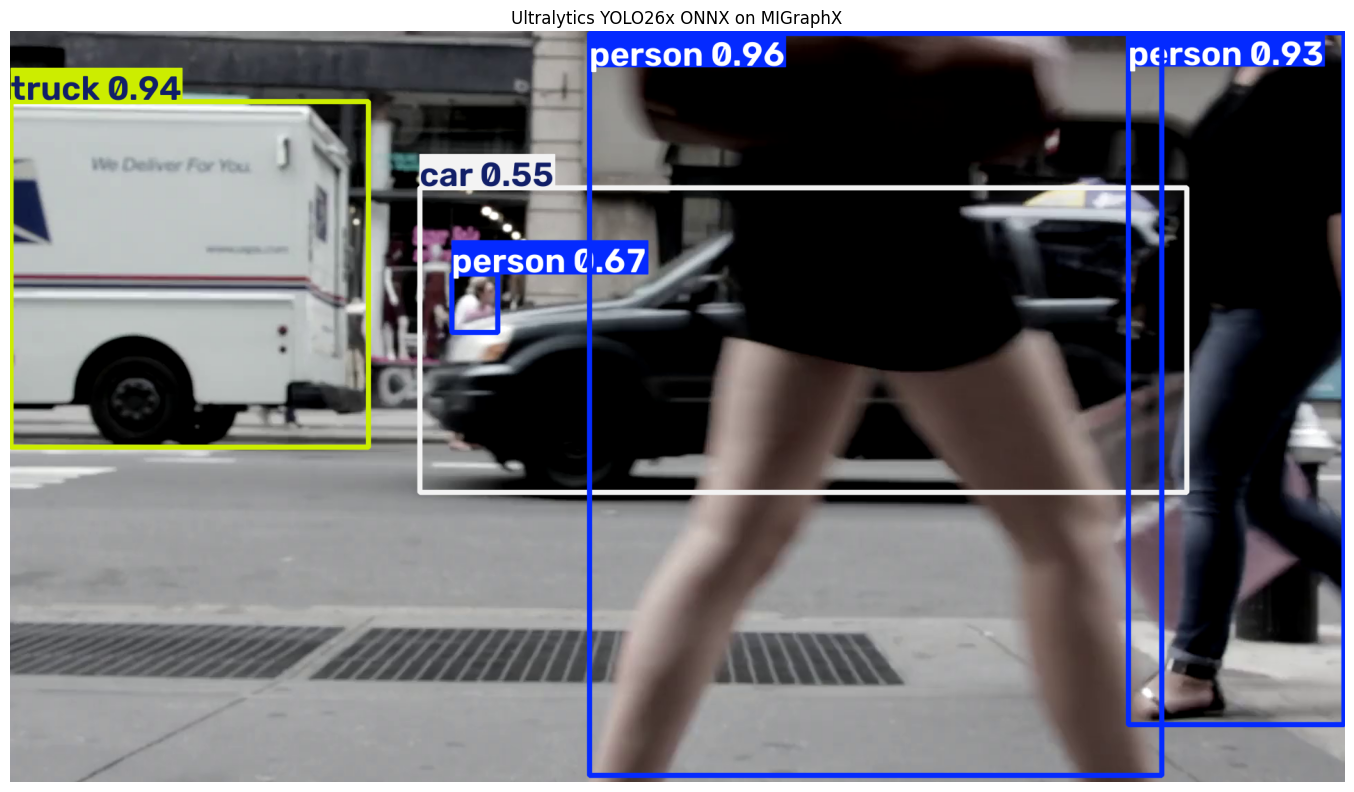

In [3]:
import gc
import math
import statistics

import cv2
import torch

from migraphx_cache import prepare_cache

USE_FRESH_EXPORT = os.environ.get(
    "USE_FRESH_EXPORT", "1" if RUN_EXPORT else "0"
) == "1"
deployment_onnx = workshop_onnx if USE_FRESH_EXPORT else env.YOLO_ONNX
deployment_sha256 = hashlib.sha256(deployment_onnx.read_bytes()).hexdigest()
deployment_cache_root = (
    export_dir / "ort-migraphx-cache"
    if USE_FRESH_EXPORT
    else env.MIGRAPHX_CACHE
)
deployment_cache_root.mkdir(parents=True, exist_ok=True)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(deployment_cache_root)
cache_dir, cache_identity = prepare_cache(deployment_onnx, deployment_cache_root, 0)

capture = cv2.VideoCapture(str(env.SOURCE_VIDEO))
ok, first_frame = capture.read()
capture.release()
assert ok

construct_started = time.perf_counter()
yolo = YOLO(str(deployment_onnx), task="detect")
construct_ms = (time.perf_counter() - construct_started) * 1000

torch.cuda.synchronize()
first_started = time.perf_counter()
result = yolo.predict(
    first_frame,
    device=0,
    half=True,
    imgsz=640,
    conf=0.5,
    iou=0.45,
    verbose=False,
)[0]
torch.cuda.synchronize()
first_predict_ms = (time.perf_counter() - first_started) * 1000

predict_samples_ms = []
for _ in range(12):
    torch.cuda.synchronize()
    started = time.perf_counter()
    result = yolo.predict(
        first_frame,
        device=0,
        half=True,
        imgsz=640,
        conf=0.5,
        iou=0.45,
        verbose=False,
    )[0]
    torch.cuda.synchronize()
    predict_samples_ms.append((time.perf_counter() - started) * 1000)

backend = yolo.predictor.model.backend
assert backend.provider == "MIGraphXExecutionProvider"
assert backend.use_io_binding and backend.migraphx_fp16
ordered_predict = sorted(predict_samples_ms)
predict_p50_ms = statistics.median(predict_samples_ms)
predict_p95_ms = ordered_predict[math.ceil(len(ordered_predict) * 0.95) - 1]
result_plot = result.plot()
backend_timing = {
    "onnx": str(deployment_onnx),
    "fresh_export_selected": USE_FRESH_EXPORT,
    "provider": backend.provider,
    "io_binding": backend.use_io_binding,
    "migraphx_fp16": backend.migraphx_fp16,
    "cache": str(cache_dir),
    "construct_ms": round(construct_ms, 3),
    "first_predict_ms": round(first_predict_ms, 3),
    "steady_predict_p50_ms": round(predict_p50_ms, 3),
    "steady_predict_p95_ms": round(predict_p95_ms, 3),
    "single_call_rate_from_p50": round(1000 / predict_p50_ms, 1),
    "boxes": len(result.boxes),
}
print(json.dumps(backend_timing, indent=2))
show_bgr(result_plot, "Ultralytics YOLO26x ONNX on MIGraphX")

del result, yolo, backend
gc.collect()
torch.cuda.empty_cache()

## 4. Measure the transfer tax: H2D and D2H

`H2D` copies host memory to GPU memory. `D2H` copies GPU memory back to the host. These synchronized measurements time one preallocated copy at a time; allocation and random-data generation are outside the timed region.

We compare:

- a full `1920 x 1080` RGB frame;
- a `1 x 3 x 640 x 640` FP32 model input;
- the compact `1 x 300 x 6` FP32 model output;
- pageable and pinned host memory.

Pinned memory can enable asynchronous DMA, but `non_blocking=True` alone does not make a dependency disappear. This cell synchronizes after every copy to measure completion rather than enqueue time. The exact numbers are machine-specific; the payload-size contrast is the transferable lesson.

In [4]:
from IPython.display import display
import pandas as pd


def percentile(values, fraction):
    ordered = sorted(values)
    return ordered[math.ceil(len(ordered) * fraction) - 1]


def measure_transfer(operation, payload_bytes, repeats=50, warmup=5):
    for _ in range(warmup):
        operation()
        torch.cuda.synchronize()
    samples_ms = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        started = time.perf_counter()
        operation()
        torch.cuda.synchronize()
        samples_ms.append((time.perf_counter() - started) * 1000)
    p50_ms = statistics.median(samples_ms)
    p95_ms = percentile(samples_ms, 0.95)
    return {
        "p50_ms": round(p50_ms, 4),
        "p95_ms": round(p95_ms, 4),
        "effective_GBps": round(payload_bytes / (p50_ms * 1_000_000), 3),
        "share_of_25fps_budget_pct": round(p50_ms / 40.0 * 100, 2),
    }


transfer_cases = [
    ("1080p RGB frame", (1080, 1920, 3), torch.uint8),
    ("640x640 model input", (1, 3, 640, 640), torch.float32),
    ("300x6 compact output", (1, 300, 6), torch.float32),
]
transfer_results = []
for payload_name, shape, dtype in transfer_cases:
    pageable_source = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_source = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    gpu_buffer = torch.empty(shape, dtype=dtype, device="cuda:0")
    pageable_destination = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_destination = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    payload_bytes = gpu_buffer.numel() * gpu_buffer.element_size()
    operations = [
        ("H2D", "pageable", lambda: gpu_buffer.copy_(pageable_source, non_blocking=False)),
        ("H2D", "pinned", lambda: gpu_buffer.copy_(pinned_source, non_blocking=True)),
        ("D2H", "pageable", lambda: pageable_destination.copy_(gpu_buffer, non_blocking=False)),
        ("D2H", "pinned", lambda: pinned_destination.copy_(gpu_buffer, non_blocking=True)),
    ]
    for direction, host_memory, operation in operations:
        transfer_results.append({
            "payload": payload_name,
            "direction": direction,
            "host_memory": host_memory,
            "payload_MiB": round(payload_bytes / 1024**2, 3),
            **measure_transfer(operation, payload_bytes),
        })

transfer_table = pd.DataFrame(transfer_results)
display(transfer_table)

,payload,direction,host_memory,payload_MiB,p50_ms,p95_ms,effective_GBps,share_of_25fps_budget_pct
0,1080p RGB frame,H2D,pageable,5.933,0.2537,0.2598,24.516,0.63
1,1080p RGB frame,H2D,pinned,5.933,0.2428,0.2451,25.626,0.61
2,1080p RGB frame,D2H,pageable,5.933,0.2438,0.2507,25.515,0.61
3,1080p RGB frame,D2H,pinned,5.933,0.2333,0.2361,26.659,0.58
4,640x640 model input,H2D,pageable,4.688,0.2039,0.2060,24.111,0.51
5,640x640 model input,H2D,pinned,4.688,0.1935,0.1964,25.398,0.48
6,640x640 model input,D2H,pageable,4.688,0.1968,0.2065,24.974,0.49
7,640x640 model input,D2H,pinned,4.688,0.1859,0.1875,26.437,0.46
8,300x6 compact output,H2D,pageable,0.007,0.0447,0.0512,0.161,0.11
9,300x6 compact output,H2D,pinned,0.007,0.0260,0.0287,0.277,0.06


## 5. Remove repeated transfers with resident GPU buffers

The production adapter initializes Ultralytics once, keeps the ORT/MIGraphX backend alive, and reuses fixed input/output allocations. rocDecode produces a DLPack GPU tensor; OpenCV HIP writes directly into reusable preprocessing buffers; I/O Binding writes the model output into a stable GPU tensor.

This cell times inference only. Compare it with the high-level `predict()` result, but do not call the difference “transfer time”: the high-level API also includes preprocessing, postprocessing, and Python result construction.

In [5]:
import config as pipeline_config

pipeline_config = importlib.reload(pipeline_config)
pipeline_config.YOLO_MODEL_PATH = str(deployment_onnx)

from detector import UltralyticsYOLODetector
from preprocess import GPUPreprocessor
from video_io import RocDecodeReader

reader = RocDecodeReader(str(env.SOURCE_VIDEO), device_id=0)
processor = GPUPreprocessor((640, 640), device="cuda:0")
detector = UltralyticsYOLODetector(model_path=str(deployment_onnx), device_id=0)
try:
    ok, rgb_gpu = reader.read_gpu()
    assert ok and rgb_gpu.is_cuda
    blob_gpu, scale, pad_w, pad_h = processor.process(rgb_gpu)
    for _ in range(5):
        raw_gpu = detector.infer_gpu(blob_gpu)
    torch.cuda.synchronize()
    resident_samples_ms = []
    input_pointer = blob_gpu.data_ptr()
    output_pointer = raw_gpu.data_ptr()
    for _ in range(30):
        torch.cuda.synchronize()
        started = time.perf_counter()
        raw_gpu = detector.infer_gpu(blob_gpu)
        torch.cuda.synchronize()
        resident_samples_ms.append((time.perf_counter() - started) * 1000)
        assert blob_gpu.data_ptr() == input_pointer
        assert raw_gpu.data_ptr() == output_pointer
    detections = detector._parse_gpu(
        raw_gpu, scale, pad_w, pad_h, tuple(rgb_gpu.shape)
    )
finally:
    reader.release()

resident_inference = {
    "p50_ms": round(statistics.median(resident_samples_ms), 3),
    "p95_ms": round(percentile(resident_samples_ms, 0.95), 3),
    "input_pointer": input_pointer,
    "output_pointer": output_pointer,
}
print(json.dumps({
    "decoded": {
        "shape": list(rgb_gpu.shape),
        "device": str(rgb_gpu.device),
        "pointer": rgb_gpu.data_ptr(),
    },
    "preprocess": {**processor.pointer_info(), "shape": list(blob_gpu.shape)},
    "inference": {**detector.provider_info(), "timing": resident_inference},
    "detections": detections,
}, indent=2))
assert blob_gpu.device.type == "cuda" and raw_gpu.device.type == "cuda"

del detector, processor, raw_gpu, blob_gpu, rgb_gpu
gc.collect()
torch.cuda.empty_cache()

[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: b1555230c13b3ad622b9
Loading /tmp/notebook-run/output/export/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


[ERR]  {GetWidth}  Display width is 0.
[ERR]  {GetHeight}  Display height is 0.
2026-09-09 11:07:25.107079847 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


MIGraphX FP16 provider option is enabled; model input remains FP32.


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)


{
  "decoded": {
    "shape": [
      1080,
      1920,
      3
    ],
    "device": "cuda:0",
    "pointer": 136274025381888
  },
  "preprocess": {
    "hwc_pointer": 136277852684288,
    "blob_pointer": 136277857599488,
    "padded_pointer": 136278326640640,
    "float_hwc_pointer": 136277793964032,
    "shape": [
      1,
      3,
      640,
      640
    ]
  },
  "inference": {
    "owner": "ultralytics.YOLO",
    "ultralytics_format": "onnx",
    "provider": "MIGraphXExecutionProvider",
    "providers": [
      "MIGraphXExecutionProvider",
      "CPUExecutionProvider"
    ],
    "provider_options": {
      "migraphx_model_cache_dir": "\"/tmp/notebook-run/output/export/ort-migraphx-cache/b1555230c13b3ad622b9\"",
      "device_id": "0",
      "migraphx_external_alloc": "0",
      "migraphx_fp8_enable": "0",
      "migraphx_int8_enable": "0",
      "migraphx_bf16_enable": "0",
      "migraphx_mem_limit": "18446744073709551615",
      "migraphx_int8_calibration_table_name": "",
      

## 6. Protect correctness before optimizing further

The convenience path and production path use different letterbox implementations, so byte-identical boxes are not required. They must retain the same box count and classes, with class-matched IoU above 0.90. A faster path that fails this gate is not an optimization.

In [6]:
from tests.test_predict_production_parity import validate as validate_parity

parity = validate_parity(deployment_onnx, env.SOURCE_VIDEO, minimum_iou=0.90)
print(json.dumps(parity, indent=2))
gc.collect()
torch.cuda.empty_cache()

Loading /tmp/notebook-run/output/export/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-09 11:07:27.397484065 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: b1555230c13b3ad622b9
Loading /tmp/notebook-run/output/export/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-09 11:07:29.097204831 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)
{
  "predict_boxes": 5,
  "production_boxes": 5,
  "classes": [
    0,
    0,
    0,
    2,
    7
  ],
  "minimum_class_matched_iou": 0.9275,
  "mean_class_matched_iou": 0.978,
  "minimum_required_iou": 0.9
}


## 7. Measure every GPU-resident stage

This benchmark separates rocDecode, OpenCV HIP preprocessing, Ultralytics/MIGraphX inference, and OpenCV GPU NMS. It synchronizes every stage, reports mean/P50/P95 after warmup, and fails if any reusable pointer changes.

The benchmark excludes overlay and encoded-video transport. Its FPS is therefore a stage-boundary measurement, not the final video FPS.

In [7]:
from tests.benchmark_gpu_stages import benchmark

RUN_BENCHMARK = os.environ.get("RUN_BENCHMARK", "0") == "1"
benchmark_path = env.OUTPUT / f"benchmarks/gpu_stages_{deployment_sha256[:12]}.json"
if RUN_BENCHMARK or not benchmark_path.is_file():
    gpu_benchmark = benchmark(
        env.SOURCE_VIDEO,
        frames=120,
        warmup=10,
        model_path=deployment_onnx,
    )
    benchmark_path.parent.mkdir(parents=True, exist_ok=True)
    benchmark_path.write_text(json.dumps(gpu_benchmark, indent=2) + "\n")
else:
    gpu_benchmark = json.loads(benchmark_path.read_text())
print(json.dumps({
    "model": str(deployment_onnx),
    "stages": gpu_benchmark["stages"],
    "gpu_path_mean_ms": gpu_benchmark["gpu_path_mean_ms"],
    "gpu_path_fps": gpu_benchmark["gpu_path_fps"],
    "stable_pointers": gpu_benchmark["stable_pointers"],
}, indent=2))

Input Video Information
	Codec        : AVC/H.264
	Frame rate   : 50/2 = 25 fps
	Sequence     : Progressive
	Coded size   : [1920, 1088]
	Display area : [0, 0, 1920, 1080]
	Chroma       : YUV 420
	Bit depth    : 8
Video Decoding Params:
	Num Surfaces : 7
	Crop         : [0, 0, 1920, 1080]
	Resize       : 1920x1080

[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: b1555230c13b3ad622b9
Loading /tmp/notebook-run/output/export/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


[ERR]  {GetWidth}  Display width is 0.
[ERR]  {GetHeight}  Display height is 0.


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-09 11:07:30.907363978 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)


{
  "model": "/tmp/notebook-run/output/export/yolo26x.onnx",
  "stages": {
    "decode": {
      "mean_ms": 0.825,
      "p50_ms": 0.453,
      "p95_ms": 4.396
    },
    "preprocess": {
      "mean_ms": 0.145,
      "p50_ms": 0.144,
      "p95_ms": 0.161
    },
    "inference": {
      "mean_ms": 6.981,
      "p50_ms": 6.977,
      "p95_ms": 7.122
    },
    "gpu_nms": {
      "mean_ms": 1.067,
      "p50_ms": 1.062,
      "p95_ms": 1.135
    }
  },
  "gpu_path_mean_ms": 9.018,
  "gpu_path_fps": 110.9,
  "stable_pointers": {
    "hwc_pointer": 136277852684288,
    "blob_pointer": 136277857599488,
    "padded_pointer": 136277718466560,
    "float_hwc_pointer": 136277787672576,
    "output_pointer": 136277817040384
  }
}


## 8. Build the optimization ladder

Optimization should remove the largest repeated boundary first, then remeasure the whole relevant path:

1. **Static ONNX + MIGraphX FP16 cache** removes repeated graph interpretation and compilation.
2. **Pinned host memory** enables asynchronous DMA when a host input is unavoidable.
3. **rocDecode + DLPack** removes full-frame H2D from file decode.
4. **OpenCV HIP preprocessing** avoids a GPU-frame D2H followed by a model-input H2D.
5. **Stable buffers + ORT I/O Binding** remove model input/output round trips and allocation churn.
6. **GPU confidence filtering + NMS** reduces D2H to compact surviving detections.
7. **HIP overlay + direct VA-API** removes the full-frame D2H/raw-video pipe before encode.
8. **Sparse, separately timed VLM calls** prevent a hundreds-of-milliseconds semantic stage from defining per-frame detector throughput.

Pinned memory improves transfer mechanics; GPU residency removes the transfer. Prefer removal when the surrounding APIs allow it.

In [8]:
full_frame_transfers = transfer_table[transfer_table["payload"] == "1080p RGB frame"]
pageable_h2d = full_frame_transfers[
    (full_frame_transfers["direction"] == "H2D")
    & (full_frame_transfers["host_memory"] == "pageable")
].iloc[0]
pageable_d2h = full_frame_transfers[
    (full_frame_transfers["direction"] == "D2H")
    & (full_frame_transfers["host_memory"] == "pageable")
].iloc[0]

optimization_ledger = pd.DataFrame([
    {
        "measurement": "Ultralytics high-level predict",
        "p50_ms": backend_timing["steady_predict_p50_ms"],
        "scope": "CPU image -> Results",
        "lesson": "Convenient baseline; includes more than inference",
    },
    {
        "measurement": "1080p pageable H2D",
        "p50_ms": pageable_h2d["p50_ms"],
        "scope": "One full RGB frame",
        "lesson": "Avoid with GPU decode or overlap when unavoidable",
    },
    {
        "measurement": "1080p pageable D2H",
        "p50_ms": pageable_d2h["p50_ms"],
        "scope": "One full RGB frame",
        "lesson": "Copy compact metadata instead of full frames",
    },
    {
        "measurement": "Resident MIGraphX inference",
        "p50_ms": resident_inference["p50_ms"],
        "scope": "GPU input -> GPU output",
        "lesson": "Stable I/O Binding isolates model execution",
    },
    {
        "measurement": "GPU-resident stage path",
        "p50_ms": gpu_benchmark["gpu_path_mean_ms"],
        "scope": "Decode + preprocess + inference + GPU NMS",
        "lesson": "Measure this boundary before overlay and encode",
    },
])
display(optimization_ledger)

,measurement,p50_ms,scope,lesson
0,Ultralytics high-level predict,8.6590,CPU image -> Results,Convenient baseline; includes more than inference
1,1080p pageable H2D,0.2537,One full RGB frame,Avoid with GPU decode or overlap when unavoidable
2,1080p pageable D2H,0.2438,One full RGB frame,Copy compact metadata instead of full frames
3,Resident MIGraphX inference,6.8820,GPU input -> GPU output,Stable I/O Binding isolates model execution
4,GPU-resident stage path,9.0180,Decode + preprocess + inference + GPU NMS,Measure this boundary before overlay and encode


## 9. Measure VLM input and output separately

The released workflow keeps Qwen3-VL as a separate scene-analysis pass. Every four-second segment becomes one three-frame storyboard, one HTTP request, and one caption. This is not detector-driven reasoning, and its latency must not be folded into YOLO FPS.

The cell displays exactly what the VLM received and what it returned. Set `RUN_VLM_LIVE=1` to repeat the first request against the persistent llama.cpp service; otherwise it reuses the verified timeline.

In [9]:
from scripts import pipeline_workflow as workflow

RUN_VLM_LIVE = os.environ.get("RUN_VLM_LIVE", "0") == "1"
if workflow.TIMELINE.is_file():
    timeline = json.loads(workflow.TIMELINE.read_text())
    first_segment = timeline["segments"][0]
    storyboard_path = workflow.RUN_DIR / first_segment["storyboard"]
    storyboard = cv2.imread(str(storyboard_path))
    assert storyboard is not None
    show_bgr(storyboard, "Qwen3-VL input: three chronological full-scene frames")

    vlm_record = {
        "backend": timeline["backend"],
        "model": timeline["model"],
        "interval_seconds": timeline["interval_seconds"],
        "input": str(storyboard_path),
        "sample_times": first_segment["sample_times"],
        "output": first_segment["caption"],
        "latency_seconds": first_segment["latency_seconds"],
        "source": "verified timeline",
    }
    if RUN_VLM_LIVE:
        from vlm_client import LlamaCppVLMClient

        client = LlamaCppVLMClient(base_url=env.LLAMACPP_BASE_URL)
        assert client.health_check()
        started = time.perf_counter()
        live_output = client.describe_roi(storyboard, timeline["prompt"])
        vlm_record.update({
            "output": live_output,
            "latency_seconds": round(time.perf_counter() - started, 3),
            "source": "live request",
        })
    print(json.dumps(vlm_record, indent=2))
else:
    print("Run the End-to-end Notebook once to generate the verified Qwen3-VL timeline.")

Run the End-to-end Notebook once to generate the verified Qwen3-VL timeline.


## 10. Connect the optimized stages to the unchanged production workflow

The production command still runs the released YOLO-only GPU path. It forces rocDecode and `vaapi-direct`: a bounded worker queue holds the resident RGB tensor, then a dedicated HIP stream performs RGB-to-NV12, box/text overlay, and submission to a DRM PRIME VA-API surface.

The End-to-end Notebook runs this command and then performs the existing VLM scene-analysis/render pass. This Step-by-step Notebook explains the costs; it does not change their orchestration.

In [10]:
from scripts import pipeline_workflow as workflow

os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(env.MIGRAPHX_CACHE)
print("Production YOLO command:")
print(" ".join(workflow.pipeline_command(max_frames=120)))
print("VA-API device:", os.environ.get("VAAPI_DEVICE", "/dev/dri/renderD128"))

if workflow.MANIFEST.is_file():
    manifest = json.loads(workflow.MANIFEST.read_text())
    print(json.dumps(manifest["pipeline"]["performance"], indent=2))
else:
    print("Run the End-to-end Notebook to create the production manifest.")

Production YOLO command:
/opt/venv/bin/python3 /job/source/src/pipeline.py --input /job/source/data/sidewalk.mp4 --output /tmp/notebook-run/output/pipeline/01_yolo_base.mp4 --no-vlm --video-decode rocdecode --video-encode vaapi --gpu-direct-encode on --max-frames 120
VA-API device: /dev/dri/renderD128
Run the End-to-end Notebook to create the production manifest.


## 11. Copy audit and takeaways

### Final YOLO/no-VLM production path

```text
H.264
  -> rocDecode GPU frame
  -> OpenCV HIP preprocess
  -> Ultralytics / ORT MIGraphX FP16 with I/O Binding
  -> OpenCV GPU filtering and NMS
  -> compact detections D2H
  -> HIP overlay + RGB-to-NV12
  -> direct VA-API H.264 encode
```

There is no full-frame D2H in this path. Compact boxes/classes/scores cross to the host after GPU NMS. Notebook visualization, the JPEG/HTTP VLM input, and the subtitle renderer remain explicit host boundaries.

### Optimization method

1. Define the measurement boundary.
2. Warm up compilation and caches.
3. Synchronize asynchronous hardware before stopping a latency timer.
4. Separate model execution from preprocessing, postprocessing, and transport.
5. Remove repeated full-frame copies before micro-optimizing kernels.
6. Reuse allocations and verify pointer stability.
7. Protect every optimization with a parity or artifact-integrity gate.
8. Report P50/P95 and environment load, not only the best FPS.

**Takeaway:** moving a model to the GPU is only the first step. A fast pipeline keeps data on the right device, moves only compact results, overlaps independent work, and measures the entire boundary it claims to optimize.